# 🏢 Exercício de Análise: Chinook Digital Media Store.

Contexto:

Você é o cientista de Dados da Chinook. Responda às demandas das diferentes áreas da empresa utilizando manipulação de dados e visualização.

## Dataset: Chinook Digital Media Store 🎵

Este é um banco de dados que simula uma loja digital de música.

Tabelas Disponíveis (baixadas no código):

1. customers: Dados dos clientes (ID, Nome, País...).

2. invoices: Cabeçalho das notas fiscais (Data, Valor Total, ID do Cliente).

3. invoice_items: Itens da nota (Qual música foi comprada, preço unitário).

4. tracks: Detalhes da música (Nome, Gênero, Duração).

### Preparação:

O código a seguir baixa os dados e cria o ambiente SQL.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import kagglehub
import os

sns.set_style("whitegrid")

path = kagglehub.dataset_download("ranasabrii/chinook")

try:
    db_path = os.path.join(path, "Chinook_Sqlite.sqlite")
    conn = sqlite3.connect(db_path)
    customers = pd.read_sql_query("SELECT * FROM Customer", conn)
    invoices = pd.read_sql_query("SELECT * FROM Invoice", conn)
    invoice_items = pd.read_sql_query("SELECT * FROM InvoiceLine", conn)
    tracks = pd.read_sql_query("SELECT * FROM Track", conn)

    print("DataFrames carregados com sucesso!")

except Exception as e:
    print(f"Erro: {e}")


Using Colab cache for faster access to the 'chinook' dataset.
DataFrames carregados com sucesso!


### Visualização inicial das tabelas para ambientação.

In [2]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59 entries, 0 to 58
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   CustomerId    59 non-null     int64 
 1   FirstName     59 non-null     object
 2   LastName      59 non-null     object
 3   Company       10 non-null     object
 4   Address       59 non-null     object
 5   City          59 non-null     object
 6   State         30 non-null     object
 7   Country       59 non-null     object
 8   PostalCode    55 non-null     object
 9   Phone         58 non-null     object
 10  Fax           12 non-null     object
 11  Email         59 non-null     object
 12  SupportRepId  59 non-null     int64 
dtypes: int64(2), object(11)
memory usage: 6.1+ KB


In [3]:
invoices.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 412 entries, 0 to 411
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   InvoiceId          412 non-null    int64  
 1   CustomerId         412 non-null    int64  
 2   InvoiceDate        412 non-null    object 
 3   BillingAddress     412 non-null    object 
 4   BillingCity        412 non-null    object 
 5   BillingState       210 non-null    object 
 6   BillingCountry     412 non-null    object 
 7   BillingPostalCode  384 non-null    object 
 8   Total              412 non-null    float64
dtypes: float64(1), int64(2), object(6)
memory usage: 29.1+ KB


In [5]:
invoice_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   InvoiceLineId  2240 non-null   int64  
 1   InvoiceId      2240 non-null   int64  
 2   TrackId        2240 non-null   int64  
 3   UnitPrice      2240 non-null   float64
 4   Quantity       2240 non-null   int64  
dtypes: float64(1), int64(4)
memory usage: 87.6 KB


In [6]:
tracks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3503 entries, 0 to 3502
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TrackId       3503 non-null   int64  
 1   Name          3503 non-null   object 
 2   AlbumId       3503 non-null   int64  
 3   MediaTypeId   3503 non-null   int64  
 4   GenreId       3503 non-null   int64  
 5   Composer      2525 non-null   object 
 6   Milliseconds  3503 non-null   int64  
 7   Bytes         3503 non-null   int64  
 8   UnitPrice     3503 non-null   float64
dtypes: float64(1), int64(6), object(2)
memory usage: 246.4+ KB


### As Requisições:

#### 1. Demandas do Diretor Comercial (Ranking de Mercados)

- A Pergunta: Quais são os países que mais geram receita para a nossa loja?

- O Desafio: As informações de país estão atreladas ao cliente, mas os valores financeiros estão nas notas fiscais. Crie uma tabela que mostre o faturamento total por país, do maior para o menor.

- Entrega: Um DataFrame (ou Series) chamado ```df_country_sales```. Imprima os 5 primeiros resultados.

In [12]:
df_merged = customers.merge(invoices, on='CustomerId')

df_country_sales = df_merged.groupby("Country")["Total"].sum().reset_index()

df_country_sales = df_country_sales.rename(columns = {"Total" : "SalesTotal"})

df_country_sales = df_country_sales.sort_values("SalesTotal", ascending = False)

df_country_sales = df_country_sales.set_index("Country")

print(df_country_sales.head())


         SalesTotal
Country            
USA          523.06
Canada       303.96
France       195.10
Brazil       190.10
Germany      156.48


#### 2. Demandas da Auditoria Interna (Inventário Completo)
- A Pergunta: Quantos itens individuais (faixas) já foram comercializados na história da loja?

- O Desafio: A auditoria precisa de uma tabela unificada que contenha o cabeçalho de todas as notas fiscais geradas e, lado a lado, os detalhes de cada item comprado nelas. Garanta estruturalmente que o seu método de junção não deixe nenhuma nota fiscal de fora, mesmo que (por um erro de sistema) ela não tenha itens registrados.

- Entrega: Após construir essa tabela unificada, conte o total de itens e armazene esse valor numérico na variável inteira ```total_items_sold```.

In [13]:
df_detailed  = invoices.merge(invoice_items, on = "InvoiceId", how = "outer", suffixes = ["_invoices", "_invoice_items"])
df_detailed  = df_detailed.merge(tracks, on = "TrackId", how = "left", suffixes = ["_total_items_sold", "_tracks"])
total_items_sold = df_detailed.shape[0]
print(total_items_sold)


2240


#### 3. Demandas da Engenharia de Software (Análise de Duração)

- A Pergunta: Qual é a duração típica de um arquivo de áudio no nosso banco de dados?

- O Desafio: A equipe de infraestrutura suspeita que existem algumas poucas faixas gigantes (como audiobooks de várias horas) na tabela de faixas (tracks) que estão a distorcer a percepção da duração média. Calcule as medidas estatísticas necessárias para provar ou refutar essa teoria.

- Entrega: Calcule as variáveis ```duracao_media``` e ```duracao_mediana```. Adicione um comentário curto no código explicando qual das duas métricas é mais confiável neste cenário e o porquê, baseado na diferença entre elas.

In [9]:
duracao_media = tracks["Milliseconds"].mean()
duracao_mediana = tracks["Milliseconds"].median()
print(f"A media de tempo das faixas é de {round(duracao_media/1000,2)} segundos.")
print(f"A mediana da série é de {round(duracao_mediana/1000,2)} segundos.")

#Observe que para casos onde há valores discrepantes (outliers) a mediana é mais precisa, pois indica
# o ponto central da série, evitando o enviesamento causado pelos valores discrepantes.

A media de tempo das faixas é de 393.6 segundos.
A mediana da série é de 255.63 segundos.


#### 4. Demandas do Time de Precificação (Relação de Variáveis).

- A Pergunta: Faixas mais longas e mais pesadas são obrigatoriamente as mais caras?

- O Desafio: Construa uma única visualização de dados que permita analisar a relação entre duração, tamanho em disco e preço unitário das faixas.

- Entrega: Um gráfico que exponha a relação entre essas três variáveis simultaneamente.

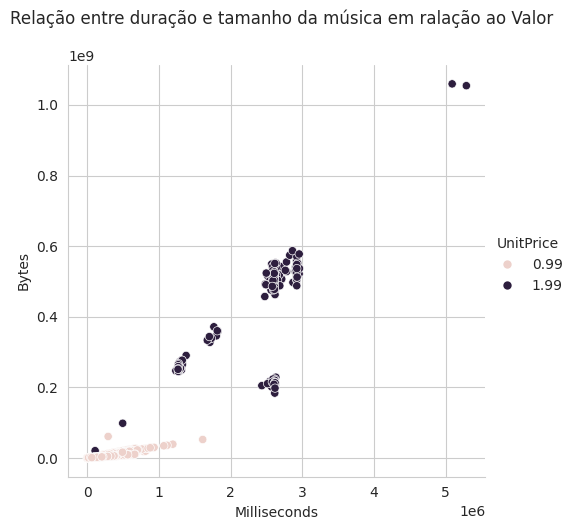

In [10]:
g = sns.relplot(x = "Milliseconds", y= "Bytes", data = tracks, hue = "UnitPrice")
g.figure.suptitle("Relação entre duração e tamanho da música em ralação ao Valor", y = 1.05)
plt.show()


#### 5. Demandas do CEO (Evolução Financeira)

- A Pergunta: Como tem sido a evolução do nosso faturamento ano a ano?

- O Desafio: O CEO quer um gráfico clássico de linha mostrando o crescimento (ou queda) da receita total agrupada por ano.
- Entrega: O gráfico gerado na tela, contendo obrigatoriamente um título claro e rótulos para os eixos X e Y.

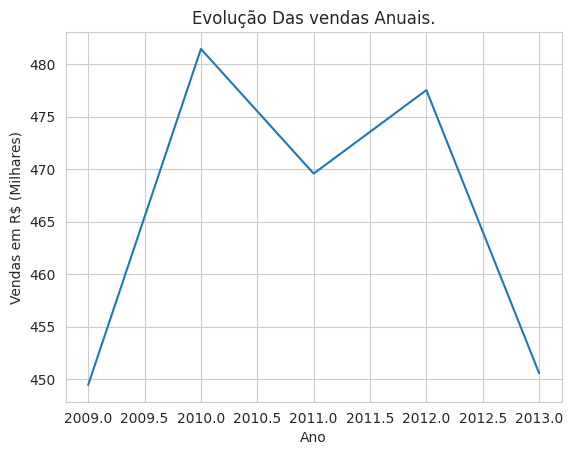

In [11]:
invoices["InvoiceDate"] = pd.to_datetime(invoices["InvoiceDate"])
invoices["anos"] = invoices["InvoiceDate"].dt.year
vendas = invoices.groupby("anos")["Total"].sum()

fig, ax = plt.subplots()

ax.plot(vendas)
ax.set_title("Evolução Das vendas Anuais.")
ax.set_xlabel('Ano')
ax.set_ylabel('Vendas em R$ (Milhares)')
plt.show()